In [106]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [107]:
# 1) Veriyi oku
df = pd.read_csv("Titanic-Dataset.csv")

In [108]:
# 2) X / y ayır
y = df["Survived"]
X = df.drop(columns=["Survived"])

In [109]:
# (İsteğe bağlı) modelde kullanmayacağın sütunları at
# Name, Ticket, PassengerId genelde atılır; Cabin'i şimdilik kullanmıyoruz
drop_cols = [c for c in ["PassengerId", "Name", "Ticket", "Cabin"] if c in X.columns]
X = X.drop(columns=drop_cols)

In [110]:
# 3) Sütun listeleri
categorical_features = ['Sex', 'Embarked', 'Pclass']   # Pclass'ı kategorik ele alıyoruz
numeric_features = [c for c in ['Age', 'Fare', 'SibSp', 'Parch'] if c in X.columns]

In [111]:
# 4) Dönüştürücüler
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))  # Age, Fare vb. için ortalama ile doldur
])

In [112]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Sex/Embarked/Pclass boşsa en sık değer
    # sklearn>=1.2 için sparse_output; eski sürümlerde 'sparse=False' kullanılır
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

In [113]:
# 5) ColumnTransformer ile hepsini birleştir
ct = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [114]:
# 6) Fit + transform
X_prepared = ct.fit_transform(X)  # NumPy array döner

In [115]:
# 7) Özellik isimlerini al ve DataFrame'e çevir
#   - Kategorik isimler (onehot sonrası)
ohe = ct.named_transformers_["cat"]["onehot"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
#   - Sayısal isimler
num_feature_names = numeric_features
feature_names = num_feature_names + cat_feature_names

In [116]:
X_final = pd.DataFrame(X_prepared, columns=feature_names, index=X.index)

# 8) Kontrol
print("X_final shape:", X_final.shape)
print(X_final.head(10))

X_final shape: (891, 12)
         Age     Fare  SibSp  Parch  Sex_female  Sex_male  Embarked_C  \
0  22.000000   7.2500    1.0    0.0         0.0       1.0         0.0   
1  38.000000  71.2833    1.0    0.0         1.0       0.0         1.0   
2  26.000000   7.9250    0.0    0.0         1.0       0.0         0.0   
3  35.000000  53.1000    1.0    0.0         1.0       0.0         0.0   
4  35.000000   8.0500    0.0    0.0         0.0       1.0         0.0   
5  29.699118   8.4583    0.0    0.0         0.0       1.0         0.0   
6  54.000000  51.8625    0.0    0.0         0.0       1.0         0.0   
7   2.000000  21.0750    3.0    1.0         0.0       1.0         0.0   
8  27.000000  11.1333    0.0    2.0         1.0       0.0         0.0   
9  14.000000  30.0708    1.0    0.0         1.0       0.0         1.0   

   Embarked_Q  Embarked_S  Pclass_1  Pclass_2  Pclass_3  
0         0.0         1.0       0.0       0.0       1.0  
1         0.0         0.0       1.0       0.0       0.0

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test = train_test_split(X_final,y,test_size=0.2,random_state=42)

In [119]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(X_train)

[[ 1.22920747 -0.07868358 -0.47072241 ...  1.8352379  -0.51880845
  -1.1258401 ]
 [-0.50350514 -0.37714494 -0.47072241 ... -0.54488848  1.92749365
  -1.1258401 ]
 [ 0.18957991 -0.47486697 -0.47072241 ... -0.54488848 -0.51880845
   0.8882256 ]
 ...
 [ 0.88266495 -0.35580399  1.23056874 ... -0.54488848 -0.51880845
   0.8882256 ]
 [-1.19659018  1.68320121  0.37992316 ...  1.8352379  -0.51880845
  -1.1258401 ]
 [-0.65752403  0.86074761 -0.47072241 ...  1.8352379  -0.51880845
  -1.1258401 ]]


In [121]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)


In [122]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[89 16]
 [20 54]]


0.7988826815642458

<Axes: >

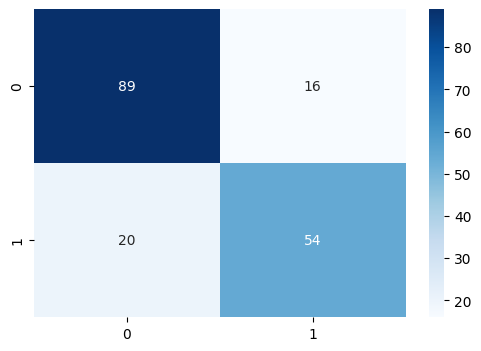

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
# Sınıf isimlerini al (label encoder kullanmadığın için y'den uniq isimler)
labels = np.unique(y)
# Görselleştirme
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

# Öncelikle Boş verilere bakalım

In [68]:
# eksik verileri listeleyelim
print('Missing values Percentage: \n\n', round (df.isnull().sum().sort_values(ascending=False)/len(df)*100,1))
print(df.isna().any())

Missing values Percentage: 

 Cabin          77.1
Age            19.9
Embarked        0.2
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
dtype: float64
PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool


# Yaş ve  Cabin boş verilerin oranlarına bakalım ilk

In [69]:
print(df[df["Age"].isna() | (df["Age"] == "")])
print("Boş Age satır sayısı", len(df[df['Age'].isna() | (df['Age']== "")]))

     PassengerId  Survived  Pclass                                      Name  \
5              6         0       3                          Moran, Mr. James   
17            18         1       2              Williams, Mr. Charles Eugene   
19            20         1       3                   Masselmani, Mrs. Fatima   
26            27         0       3                   Emir, Mr. Farred Chehab   
28            29         1       3             O'Dwyer, Miss. Ellen "Nellie"   
..           ...       ...     ...                                       ...   
859          860         0       3                          Razi, Mr. Raihed   
863          864         0       3         Sage, Miss. Dorothy Edith "Dolly"   
868          869         0       3               van Melkebeke, Mr. Philemon   
878          879         0       3                        Laleff, Mr. Kristo   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   

        Sex  Age  SibSp  Parch      Tic

In [70]:
print(df[df['Cabin'].isna() | (df['Cabin'] == "")])
print("Boş Kabin veri satırı", len(df[df['Cabin'].isna() | (df['Cabin'] == "")]))

     PassengerId  Survived  Pclass                                      Name  \
0              1         0       3                   Braund, Mr. Owen Harris   
2              3         1       3                    Heikkinen, Miss. Laina   
4              5         0       3                  Allen, Mr. William Henry   
5              6         0       3                          Moran, Mr. James   
7              8         0       3            Palsson, Master. Gosta Leonard   
..           ...       ...     ...                                       ...   
884          885         0       3                    Sutehall, Mr. Henry Jr   
885          886         0       3      Rice, Mrs. William (Margaret Norton)   
886          887         0       2                     Montvila, Rev. Juozas   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch        

# Veriyi  ilk önce X ve y olarak bölelim

In [71]:
X = df.drop('Survived', axis = 1)
y = df['Survived']  # ya da df.iloc[:, 0]

# NumPy dizilerine çevirelim

In [72]:
X_np = X.values
y_np = y.values

# Eksik yaş verisinin üstesinden gelelim

In [73]:

# AGE sütunu (sayısal) doldurma
imputer_age = SimpleImputer(missing_values=np.nan, strategy='mean')
age_column = X_np[:, 4].reshape(-1, 1)  # Age sütunu
imputer_age.fit(age_column)
X_np[:, 4] = imputer_age.transform(age_column).ravel()

# Örnek veri kontrol edelim

In [74]:
print(X_np[5])

[6 3 'Moran, Mr. James' 'male' 29.69911764705882 0 0 '330877' 8.4583 nan
 'Q']


# Cabin sütunu üstesinden gelelim 

In [75]:
# CABIN sütunu (kategorik) doldurma
imputer_cabin = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
cabin_column = X_np[:, 8].reshape(-1, 1)  # Cabin sütunu
imputer_cabin.fit(cabin_column)
X_np[:, 8] = imputer_cabin.transform(cabin_column).ravel()

# Kontrol
print("Cabin sütunundaki eksikler:", np.sum(pd.isnull(X_np[:, 8])))

Cabin sütunundaki eksikler: 0


In [76]:
print(X_np[0])

[1 3 'Braund, Mr. Owen Harris' 'male' 22.0 1 0 'A/5 21171' 7.25 nan 'S']


In [77]:
print(y_np[0])

0
